In [1]:
# %% [markdown]
# # 01 - Data Preparation
# ## Loading and cleaning BTC-USD hourly data

# %%
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
from src import utils, config

# %%
# Load raw data
df = utils.load_and_prepare_data(config.RAW_DATA_PATH)
print(f"Raw data shape: {df.shape}")
print(df.head())

# %%
# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# %%
# Clean data
df = utils.clean_data(df)

# %%
# Save cleaned data
df.to_csv(config.CLEAN_DATA_PATH, index=False)
print(f"Cleaned data saved to {config.CLEAN_DATA_PATH}")
print(f"Final shape: {df.shape}")
print(f"Date range: {df['Datetime'].min()} to {df['Datetime'].max()}")

# %%
# Basic statistics
print("\nDescriptive statistics:")
print(df[['Close', 'High', 'Low', 'Open', 'Volume', 'returns']].describe())

Raw data shape: (17351, 6)
                   Datetime         Close          High           Low  \
0 2024-02-15 00:00:00+00:00  52360.242188  52467.960938  51829.496094   
1 2024-02-15 01:00:00+00:00  51943.589844  52371.015625  51801.421875   
2 2024-02-15 02:00:00+00:00  52122.542969  52233.503906  51959.035156   
3 2024-02-15 03:00:00+00:00  52378.894531  52394.914062  52104.105469   
4 2024-02-15 04:00:00+00:00  52203.054688  52385.132812  52193.335938   

           Open      Volume  
0  51836.785156           0  
1  52371.015625  1201115136  
2  51959.035156   699662336  
3  52104.105469   529379328  
4  52384.472656   160198656  
Missing values before cleaning:
Datetime    0
Close       0
High        0
Low         0
Open        0
Volume      0
dtype: int64
Cleaned data saved to data/processed/btc_clean.csv
Final shape: (17350, 7)
Date range: 2024-02-15 01:00:00+00:00 to 2026-02-13 10:00:00+00:00

Descriptive statistics:
               Close           High            Low        

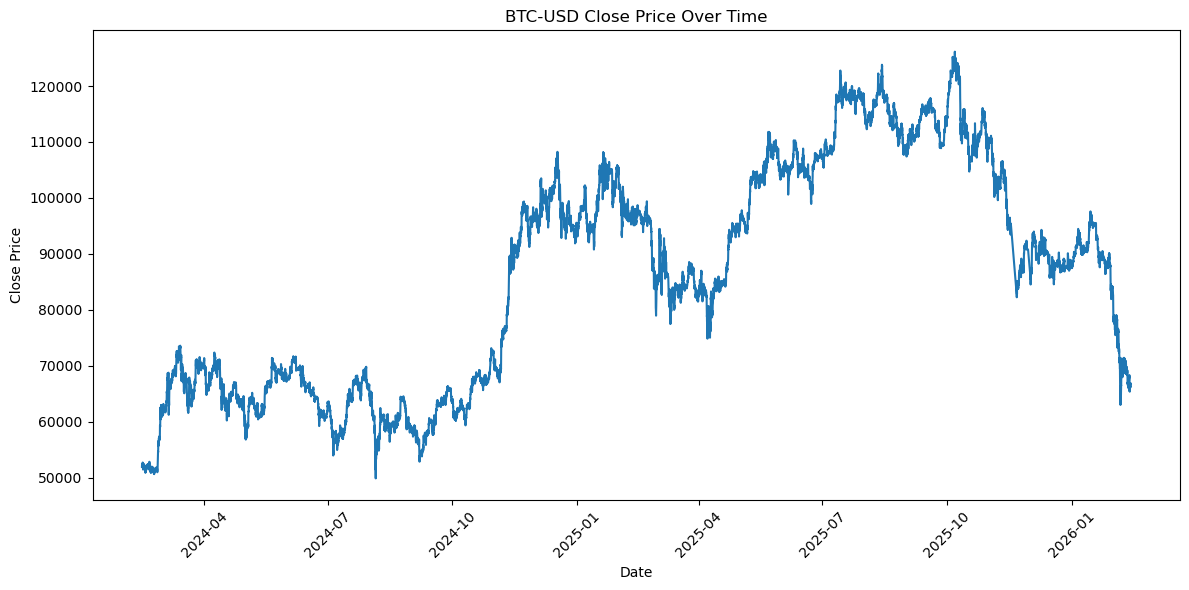

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Datetime'], df['Close'])
plt.title('BTC-USD Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


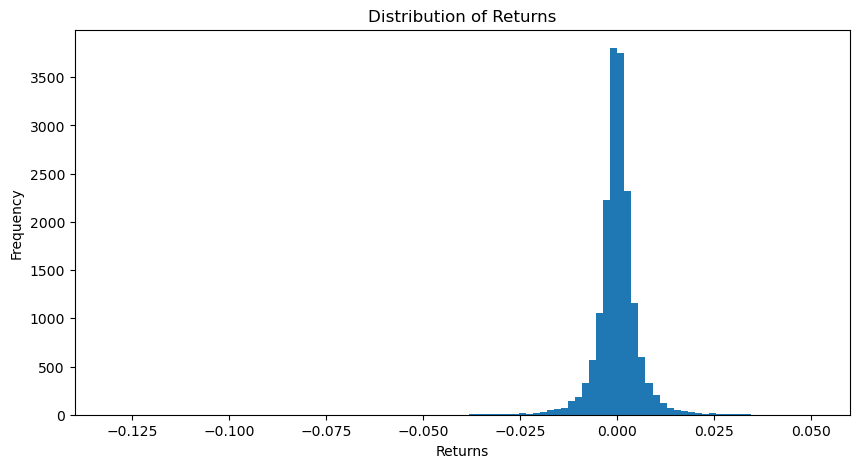

In [3]:
plt.figure(figsize=(10,5))
plt.hist(df['returns'], bins=100)
plt.title('Distribution of Returns')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.show()